# Example: solving the forward problem

In [21]:
from odil_wave import Grid
grid = Grid(nx = 50, ny = 50, xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0, c_min=1.5, c_max=1.7)

In [22]:
print(grid.summary)

Nx, Ny, Nt: 50, 50, 168
dx, dy, dt: 0.020408163m, 0.020408163m, 0.006774676s
CFL (at c_max = 1.7):  0.798
x in [0.000, 1.000]m
y in [0.000, 1.000]m


The time discretisation is computed automatically from the spatial spec according to the CFL condition.

From a `Grid`, we can start to build the other components of the problem. First, let's build a velocity model.

<Axes: title={'center': 'c(x, y) [Circular Anomaly Model]'}, xlabel='x [m]', ylabel='y [m]'>

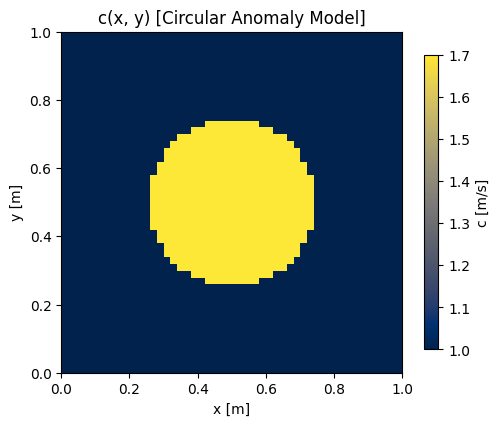

In [23]:
from odil_wave import OverDensityModel

model = OverDensityModel(grid, centre=(0.5, 0.5), radius=0.25)
model.show()

Amplitude data can be represented by a `Wavefield` object:

In [24]:
from odil_wave import Wavefield
wavefield = Wavefield(grid=grid)

Amplitude data is initialised to zero by default.

To drive wave propagation, we need a source term. We can define sources using the `Sources` class. Sources can be placed in a ring, or using custom spatial position in (x, y) coordinates. Source injection is controlled by sinc interpolation, which is a way to represent a point source exactly on a discrete grid. 

In [ ]:
from odil_wave.geometry import Sources 
sources = Sources(grid, n_sources=1, f0=10, mode="custom", source_locs=((0.5, 0.9),))

<Axes: title={'center': 'Sources on Circular Anomaly Model'}, xlabel='x [m]', ylabel='y [m]'>

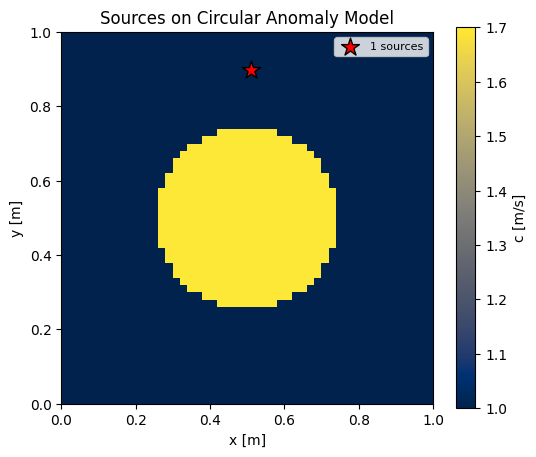

In [26]:
sources.show(model)

<Axes: title={'center': 'Ricker pulse ($f_0$=5 Hz, $t_0$=0.200 s)'}, xlabel='t [s]', ylabel='R(t) [a.u.]'>

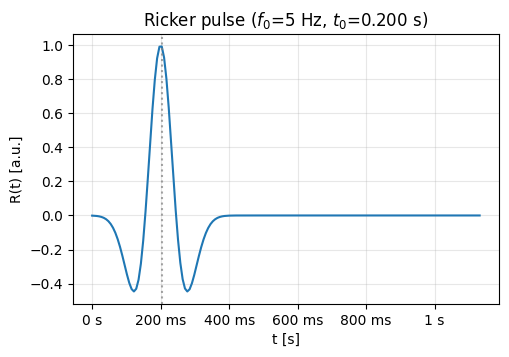

In [ ]:
sources.plot_source_pulse()

We can now move towards the physics of our problem. The discretisation scheme is controlled by operators of type `Operator` and there are a few options, but thankfully we can just specify the desired method order in time and space to a `WaveEquation` object and it will construct our operators along with objects that apply initial and boundary conditions. 

In [ ]:
from odil_wave import WaveEquation

wave_eq = WaveEquation(wavefield, model, time_order=2, space_order=2)

To form a loss function, we can use a `ForwardLoss` object that should be configured by defining our `Problem`.

In [ ]:
from odil_wave import Problem

problem = Problem(wave_eq=wave_eq, geometry=sources)

In [ ]:
from odil_wave import ForwardLoss
loss = ForwardLoss(problem=problem)

In [31]:
from odil_wave import LBFGSB
optimiser = LBFGSB(loss)

First, let's look at what the intial loss and gradient looks like:

In [32]:
import numpy as np

loss_val, grad = loss.evaluate(wavefield.U)
print("loss:", loss_val)
print("grad norm:", np.linalg.norm(grad))
print("grad max:", np.abs(grad).max())

loss: 0.11364283035987136
grad norm: 0.28958047194820674
grad max: 0.043230454402833136


Let's try to sove this small problem using a naive LBFGS.

In [39]:
from odil_wave.optimisation import LBFGSB
optimiser = LBFGSB(loss)

In [ ]:
result, tape = optimiser.minimise(wavefield, maxiter=1000, ftol=1e-6, gtol=1e-8)

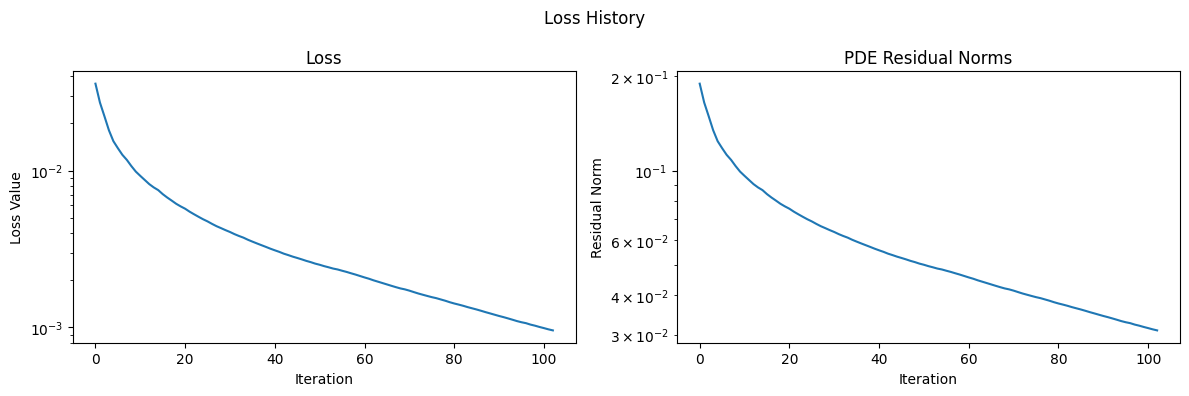

In [ ]:
tape.show()

Finally, we can use the `wavefield`'s `.animate` utility to render a gif of the amplitude history over time.

In [ ]:
outfile = result.animate(filename="wavefield-lbfgs")

We can also solve using a Gauss Newton method.

Our problem is

$$\min_u \frac 1 2 \|r\|^2,$$

where 

$$r = Au - s.$$

At iteration $k$, Gauss Newton linearises the residual around $u_k$ such that

$$r(u_k+\delta u) \approx r_k +J_k\delta u,$$

where $J_k$ is the Jacobian of the residual. For our linear system, this is simply $A$. Thus the GN step solves

$$\min_{\delta u} \frac 1 2 \|A\delta u +r_k\|^2,$$

for which the normal equations are then

$$A^TA\delta u = -A^T r_k.$$

The minimum of the least squares probem occurs when 
$$A \delta u + r = 0,$$

provided $A \in \mathbb{R}^n$. Thus the task of the inner solve is the find the solution to

$$A\delta u = -r,$$

which minimises GN in exactly one step since the functional is quadratic.

In [ ]:
from odil_wave.optimisation import GaussNewtonOptimiser
optimiser = GaussNewtonOptimiser(loss)

In [ ]:
result = optimiser.minimise(wavefield, method="paradiag", alpha=0.001)

In [35]:
result.keys()

dict_keys(['x', 'fun', 'nit', 'success', 'message', 'wavefield', 'tape', 'inner_history'])

In [ ]:
result.exit_reason

Maximum outer iterations (1) reached


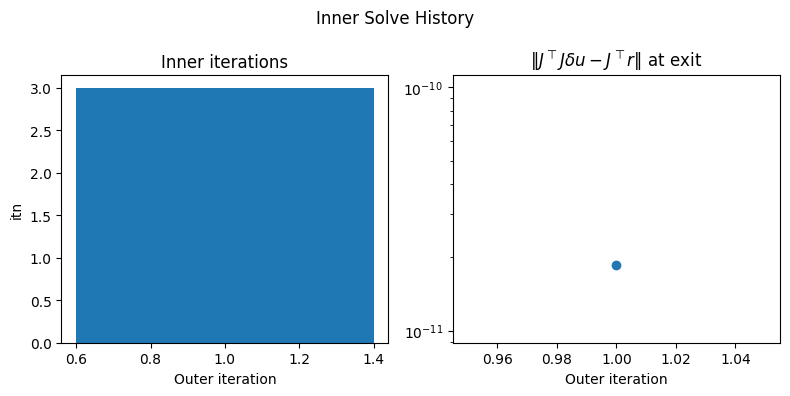

In [37]:
result.show_inner()

In [ ]:
outfile = result.solution.animate(filename="wavefield-gn.gif")